In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.9 MB/s eta 0:00:00:00:0100:01
  Attempting unins

In [2]:
import os
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split
from ultralytics import YOLO 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
original_dirs = {
    'Calculus': '/kaggle/input/oral-diseases/Calculus/Calculus',
    'Caries': '/kaggle/input/oral-diseases/Data caries/Data caries/caries augmented data set/preview',
    'Gingivitis': '/kaggle/input/oral-diseases/Gingivitis/Gingivitis',
    'Ulcers': '/kaggle/input/oral-diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview',
    'Tooth Discoloration': '/kaggle/input/oral-diseases/Tooth Discoloration/Tooth Discoloration /Tooth_discoloration_augmented_dataser/preview',
    'Hypodontia': '/kaggle/input/oral-diseases/hypodontia/hypodontia'
}

# Step 3: Create DataFrame of image paths and labels
image_paths = []
labels = []
for class_name, class_dir in original_dirs.items():
    for root, dirs, files in os.walk(class_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
                labels.append(class_name)

df = pd.DataFrame({'Image Path': image_paths, 'Label': labels})



# Step 4: Map classes to IDs
class_names = sorted(df['Label'].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
df['class_id'] = df['Label'].map(class_to_id)



In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

In [5]:
base_dir = '/kaggle/working/yolo_data'
train_images = os.path.join(base_dir, 'images/train')
val_images = os.path.join(base_dir, 'images/val')
train_labels = os.path.join(base_dir, 'labels/train')
val_labels = os.path.join(base_dir, 'labels/val')

os.makedirs(train_images, exist_ok=True)
os.makedirs(val_images, exist_ok=True)
os.makedirs(train_labels, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

In [6]:
for subset_df, subset_img_dir, subset_lbl_dir in [
    (train_df, train_images, train_labels),
    (val_df, val_images, val_labels)
]:
    for _, row in subset_df.iterrows():
        img_name = os.path.basename(row['Image Path'])
        shutil.copy(row['Image Path'], os.path.join(subset_img_dir, img_name))
        label_path = os.path.join(subset_lbl_dir, img_name.rsplit('.', 1)[0] + '.txt')
        with open(label_path, 'w') as f:
            f.write(f"{row['class_id']} 0.5 0.5 1.0 1.0\n")

In [7]:
yaml_content = f"""
train: {train_images}
val: {val_images}
nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(base_dir, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

In [8]:
model = YOLO('yolov8n.pt')  


In [9]:
model.train(data=os.path.join(base_dir, 'data.yaml'), epochs=200, imgsz=224, name='yolov8_oral_classifier')


Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_oral_classifier, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2254       2254      0.809      0.883       0.87      0.864
              Calculus        221        221      0.561      0.612      0.651      0.645
                Caries        477        477      0.988          1      0.995      0.995
            Gingivitis        440        440       0.67      0.895      0.866      0.854
            Hypodontia        241        241       0.67      0.793      0.716      0.701
   Tooth Discoloration        367        367      0.975          1      0.995      0.993
                Ulcers        508        508      0.988      0.998      0.995      0.995
Speed: 0.0ms preprocess, 0.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/yolov11_oral_classifier


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f537f5a4850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [10]:
metrics = model.val()


Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 459.7±250.5 MB/s, size: 19.9 KB)
val: Scanning /kaggle/working/yolo_data/labels/val.cache... 2254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2254/2254 4.7Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 16.6it/s 8.5s0.1s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2254       2254       0.81      0.881       0.87      0.863
              Calculus        221        221      0.569      0.609       0.65      0.643
                Caries        477        477      0.988          1      0.995      0.995
            Gingivitis        440        440       0.67      0.895      0.866      0.854
            Hypodontia        241        241      0.673      0.786      0.717        0.7
   Tooth Discoloration        367        367      0.975          1      0.995      0.993
                Ulcers        508        508      0.988      0.998      0.995      0.995
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/yolov11_oral_classifier2


In [15]:
from ultralytics import YOLO
import shutil
from IPython.display import FileLink

# Step 1: Load trained model
model = YOLO("/kaggle/working/runs/detect/yolov11_oral_classifier/weights/best.pt")

# Step 2: Copy best.pt to root working directory for easy access
shutil.copy(
    "/kaggle/working/runs/detect/yolov11_oral_classifier/weights/best.pt",
    "/kaggle/working/best.pt"
)

# Step 3: Create clickable download link
FileLink(r'best.pt')


/kaggle/working/best.pt

Available columns:
 ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


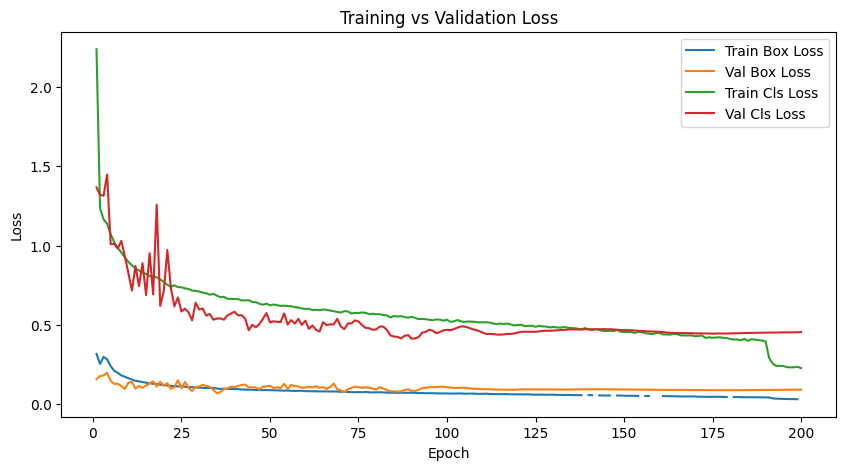

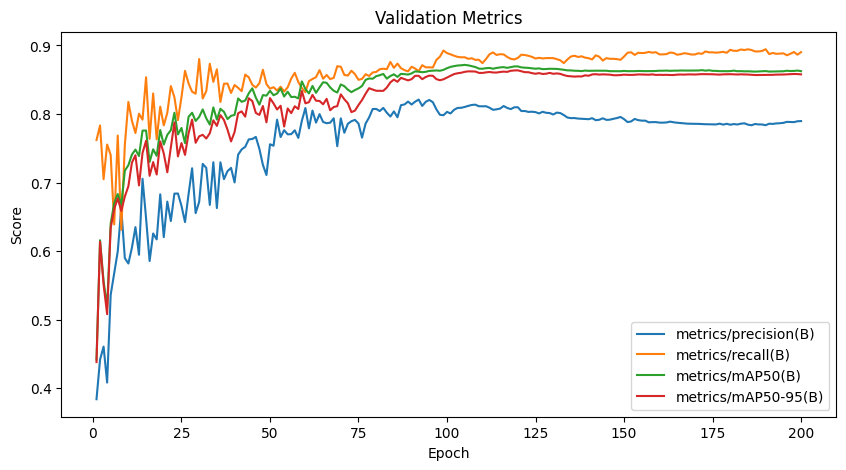

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Correct results.csv path
results_path = "/kaggle/working/runs/detect/yolov11_oral_classifier/results.csv"

# Load CSV
df = pd.read_csv(results_path)
print("Available columns:\n", df.columns.tolist())  # Debug: check what columns exist

# Plot Loss curves (only if columns exist)
plt.figure(figsize=(10,5))
if "train/box_loss" in df and "val/box_loss" in df:
    plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
    plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")

if "train/cls_loss" in df and "val/cls_loss" in df:
    plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
    plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Plot Metrics (Precision, Recall, mAP)
plt.figure(figsize=(10,5))
for col in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
    if col in df:
        plt.plot(df["epoch"], df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.show()


Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 531.2±319.1 MB/s, size: 24.8 KB)
val: Scanning /kaggle/working/yolo_data/labels/val.cache... 2254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2254/2254 3.9Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 17.3it/s 8.2s0.1s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2254       2254       0.81      0.881       0.87      0.863
              Calculus        221        221      0.569      0.609       0.65      0.643
                Caries        477        477      0.988          1      0.995      0.995
            Gingivitis        440        440       0.67      0.895      0.866      0.854
            Hypodontia        241        241      0.673      0.786      0.717        0.7
   Tooth Discoloration        367        367      0.975          1      0.995      0.993
                Ulcers        508        508      0.988      0.998      0.995      0.995
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


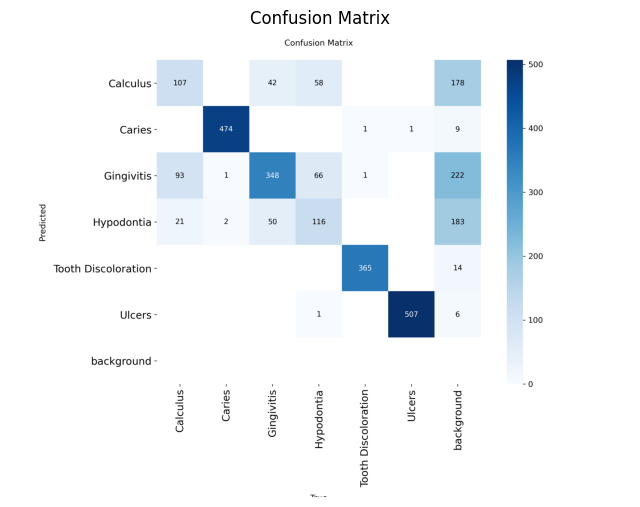

In [17]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("/kaggle/working/runs/detect/yolov11_oral_classifier/weights/best.pt")

# Run validation (this will compute metrics + confusion matrix)
metrics = model.val()

# The confusion matrix is saved automatically in the run directory:
# runs/detect/val/confusion_matrix.png

# Show it inline
img_path = "runs/detect/val/confusion_matrix.png"
img = plt.imread(img_path)
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()


Available columns:
 ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


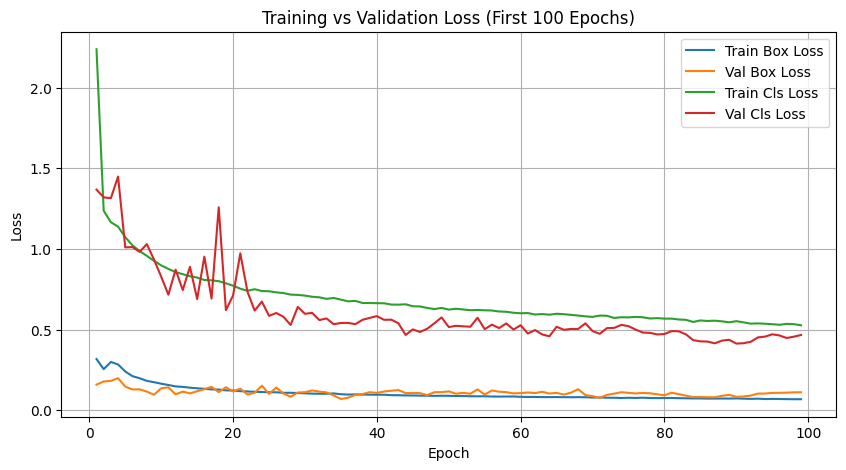

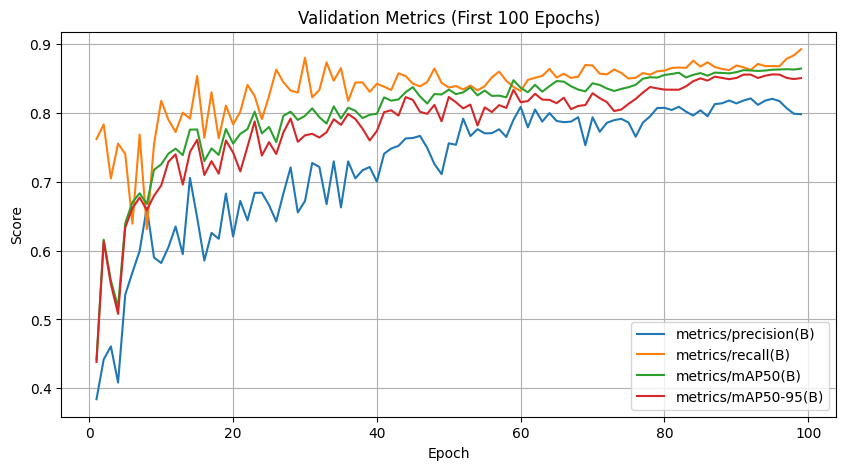

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Correct results.csv path
results_path = "/kaggle/working/runs/detect/yolov11_oral_classifier/results.csv"

# Load CSV
df = pd.read_csv(results_path)

print("Available columns:\n", df.columns.tolist())  # Debug: check what columns exist

# Ensure only first 100 epochs are considered (if file has more)
df = df[df["epoch"] < 100]  

# Plot Loss curves
plt.figure(figsize=(10,5))
if "train/box_loss" in df and "val/box_loss" in df:
    plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
    plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")

if "train/cls_loss" in df and "val/cls_loss" in df:
    plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
    plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (First 100 Epochs)")
plt.legend()
plt.grid(True)
plt.show()

# Plot Metrics (Precision, Recall, mAP)
plt.figure(figsize=(10,5))
for col in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
    if col in df:
        plt.plot(df["epoch"], df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics (First 100 Epochs)")
plt.legend()
plt.grid(True)
plt.show()


Ultralytics 8.3.201 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 491.6±209.6 MB/s, size: 23.4 KB)
val: Scanning /kaggle/working/yolo_data/labels/val.cache... 2254 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2254/2254 4.1Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 17.2it/s 8.2s0.1s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2254       2254       0.81      0.881       0.87      0.863
              Calculus        221        221      0.569      0.609       0.65      0.643
                Caries        477        477      0.988          1      0.995      0.995
            Gingivitis        440        440       0.67      0.895      0.866      0.854
            Hypodontia        241        241      0.673      0.786      0.717        0.7
   Tooth Discoloration        367        367      0.975          1      0.995      0.993
                Ulcers        508        508      0.988      0.998      0.995      0.995
Speed: 0.1ms preprocess, 0.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3


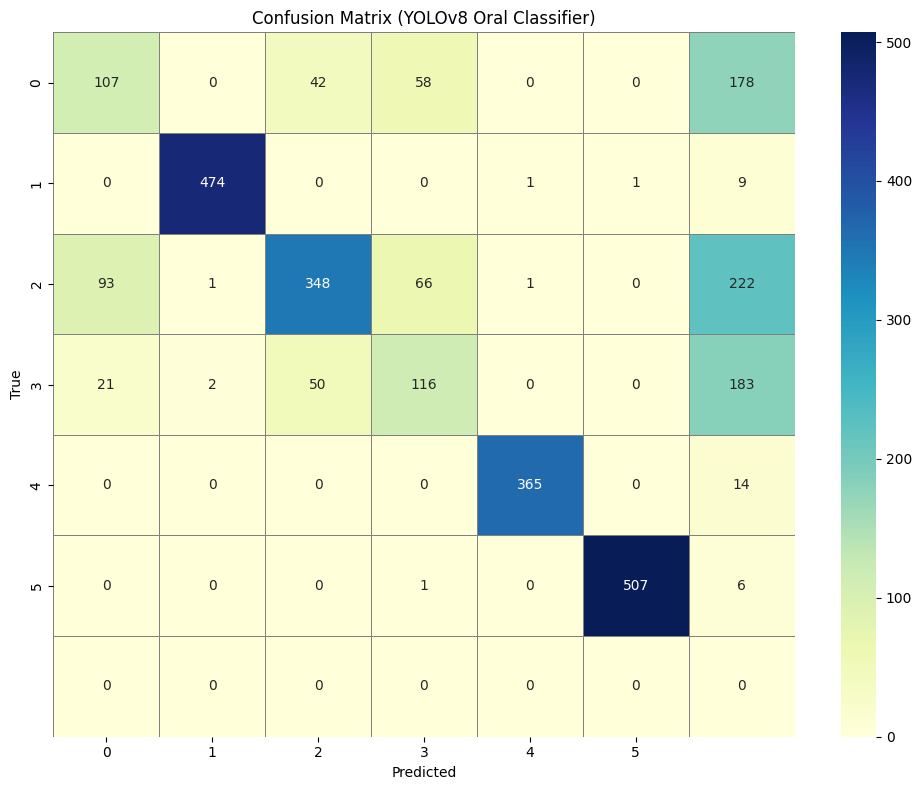

In [27]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load trained model
model = YOLO("/kaggle/working/runs/detect/yolov11_oral_classifier/weights/best.pt")

# Run validation
metrics = model.val()

# Extract confusion matrix
cm = metrics.confusion_matrix.matrix  # numpy array
class_names = metrics.names           # class labels

# Plot confusion matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",     # 🔥 alternate colormap: try "coolwarm", "magma", "cividis"
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="gray"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (YOLOv8 Oral Classifier)")
plt.tight_layout()
plt.show()
